# Parameter Estimation

I experiment on the specific case where we approximatively know the proportion of trees types:

$\lambda_{p1}/\lambda_{p2} = x $ where $\alpha \leq x \leq \beta$. $\alpha$ and $\beta$ are known.

In [8]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import g_theo_thomas
from src.utils import contrast
import json

**Simulating the superposition of two Thomas processes**

In [9]:
with open('../../parameters/superposition-c-02.json', 'r') as file:
    params = json.load(file)

In [10]:
W = params['thomas_1']['W']
w, h = W
lam_p1, lam_p2 = params['thomas_1']['lam_p'], params['thomas_2']['lam_p']
nu1, nu2 = params['thomas_1']['nu'], params['thomas_2']['nu']
sig1, sig2 = params['thomas_1']['sig'], params['thomas_2']['sig']

In [11]:
thomas_process1 = ThomasProcess(lam_p1, nu1, sig1)
parents1, points_thomas1 = thomas_process1.generate(W, seed=46)
thomas_process2 = ThomasProcess(lam_p2, nu2, sig2)
parents2, points_thomas2 = thomas_process2.generate(W, seed=46)
points_sup = np.concatenate([points_thomas1, points_thomas2])

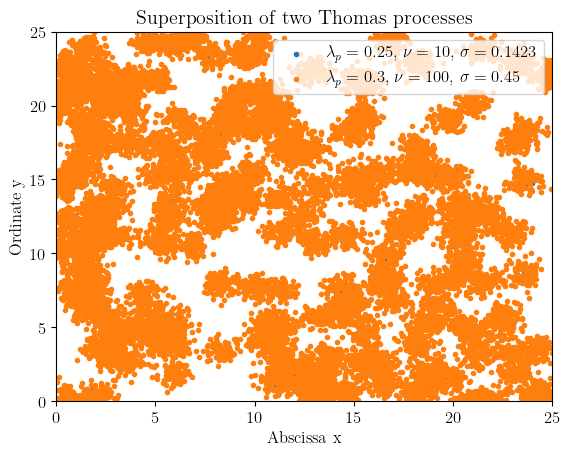

In [12]:
display_superposition([points_thomas1, points_thomas2], 
                      window=W, 
                      title="Superposition of two Thomas processes", 
                      labels=[fr'$\lambda_p = {lam_p1}$, $\nu = {nu1}$, $\sigma = {sig1}$', 
                              fr'$\lambda_p = {lam_p2}$, $\nu = {nu2}$, $\sigma = {sig2}$'])

The theoretical formula for the _p.c.f_ of the superposition of two point processes is:
$$
g(r) = \frac{\lambda_1^2g_1(r) + \lambda_2^2g_2(r) + 2 \lambda_1\lambda_2}{(\lambda_1 + \lambda_2)^2}
$$

In the following, we consider the parameter vector $\theta = (\lambda_{p,1}, \nu_1, \sigma_1, \lambda_{p,2}, \nu_2, \sigma_2)$

In [13]:
def g_theo_2thomas(r, theta):
    lam_p1, nu1, sig1, lam_p2, nu2, sig2 = theta
    g1 = g_theo_thomas(r, (lam_p1, sig1))
    g2 = g_theo_thomas(r, (lam_p2, sig2))
    lam1 = lam_p1*nu1
    lam2 = lam_p2*nu2
    return  (lam1**2*g1 + lam2**2*g2 + 2*lam1*lam2)/((lam1 + lam2)**2)

In [14]:
r_values, g_values = g(points_sup, W)  # Estimating the p.c.f

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages



In [15]:
threshold = 10  # For radii smaller than the bandwidth, the estimator explodes
r_values = r_values[threshold:]
g_values = g_values[threshold:]

In [16]:
g_theo_values = g_theo_2thomas(r_values, (lam_p1, nu1, sig1, lam_p2, nu2, sig2))

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_786021/1984828281.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(r_values, g_values, label='$\hat{g}$')
/tmp/ipykernel_786021/1984828281.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('PCF estimate $\hat{g}(r)$')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


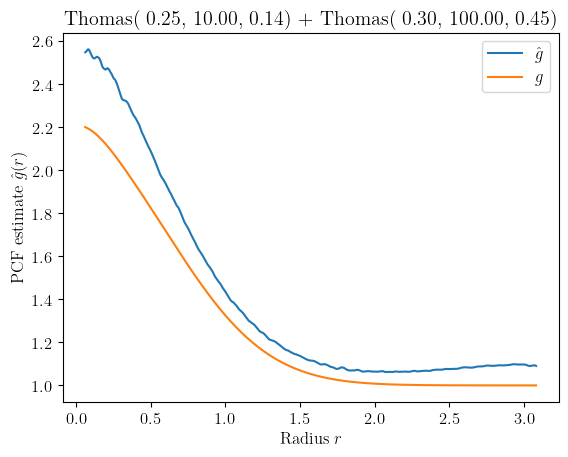

In [24]:
plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

plt.plot(r_values, g_values, label='$\hat{g}$')
plt.plot(r_values, g_theo_values, label='$g$')
plt.xlabel('Radius $r$')
plt.ylabel('PCF estimate $\hat{g}(r)$')

plt.legend()
plt.title(rf'Thomas({lam_p1: .2f}, {nu1: .2f}, {sig1: .2f}) + Thomas({lam_p2: .2f}, {nu2: .2f}, {sig2: .2f})')

plt.savefig('../../img/pcf-estim-1.eps', format='eps')
plt.show()

In [ ]:
def contrast_aux(theta):  # Auxiliary contrast function that takes theta as a parameter
    g_theo_list = g_theo_2thomas(r_values, theta)
    dr = r_values[1] - r_values[0]
    return contrast(g_values, g_theo_list, dr)

In [ ]:
from scipy.optimize import NonlinearConstraint, LinearConstraint

theta0 = [10, 1, 1, 1, 10, 1]  # Initial guess

bounds = [(1e-6, None)]*6  # Positivity constraints

alpha, beta = 9, 11

def cb(result):
    print(f'hello: {result}')

tol = 1
lb, ub = 0, tol

def theoIntensity(theta):
    lam_p1, nu1, sig1, lam_p2, nu2, sig2 = theta
    return 10*abs(lam_p1 - lam_p2) + abs(nu1/sig1**2 - nu2/sig2**2) # Hypothesis: lambdas are equal and nu1 = mu*sig1**2 and nu2 = mu*sig2**2 (# lamp_1 = lamp_2)

constraints = [NonlinearConstraint(theoIntensity, lb, ub), LinearConstraint([[0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0]], lb=[5, 95], ub=[np.inf, np.inf])]
result = minimize(contrast_aux, theta0, method='COBYLA', constraints=constraints)

print('Estimated parameters:\n------------------')
print(f'estimated_lam_p1 = {result.x[0]:.3f}')
print(f'estimated_nu1 = {result.x[1]:.3f}')
print(f'estimated_sig1 = {result.x[2]:.3f}')
print(f'estimated_lam_p2 = {result.x[3]:.3f}')
print(f'estimated_nu2 = {result.x[4]:.3f}')
print(f'estimated_sig2 = {result.x[5]:.3f}')
print('\nReal parameters:\n------------------')
print(f'lam_p1 = {lam_p1:.3f}')
print(f'nu1 = {nu1:.3f}')
print(f'sig1 = {sig1:.3f}')
print(f'lam_p2 = {lam_p2:.3f}')
print(f'nu2 = {nu2:.3f}')
print(f'sig2 = {sig2:.3f}')

Estimated parameters:
------------------
estimated_lam_p1 = 5.384
estimated_nu1 = 5.144
estimated_sig1 = 0.498
estimated_lam_p2 = 5.272
estimated_nu2 = 95.026
estimated_sig2 = 2.139

Real parameters:
------------------
lam_p1 = 0.250
nu1 = 10.000
sig1 = 0.142
lam_p2 = 0.025
nu2 = 100.000
sig2 = 0.450


In [ ]:
print(theoIntensity(result.x), lb, ub)

1.1229935673916778 0 1
